<a href="https://colab.research.google.com/github/MonikSense/GLAUCOMA/blob/main/greenretinexCALEch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input: /content/drive/MyDrive/GlaucomaDataset/G1020/Images
Output: /content/drive/MyDrive/GlaucomaDataset/G1020/preprocessed_outputs


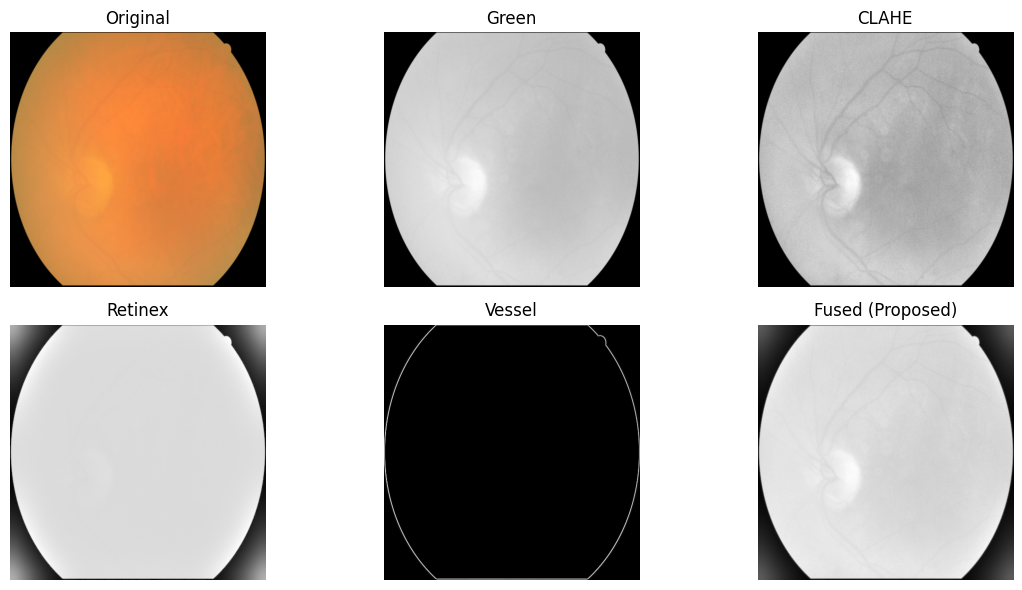

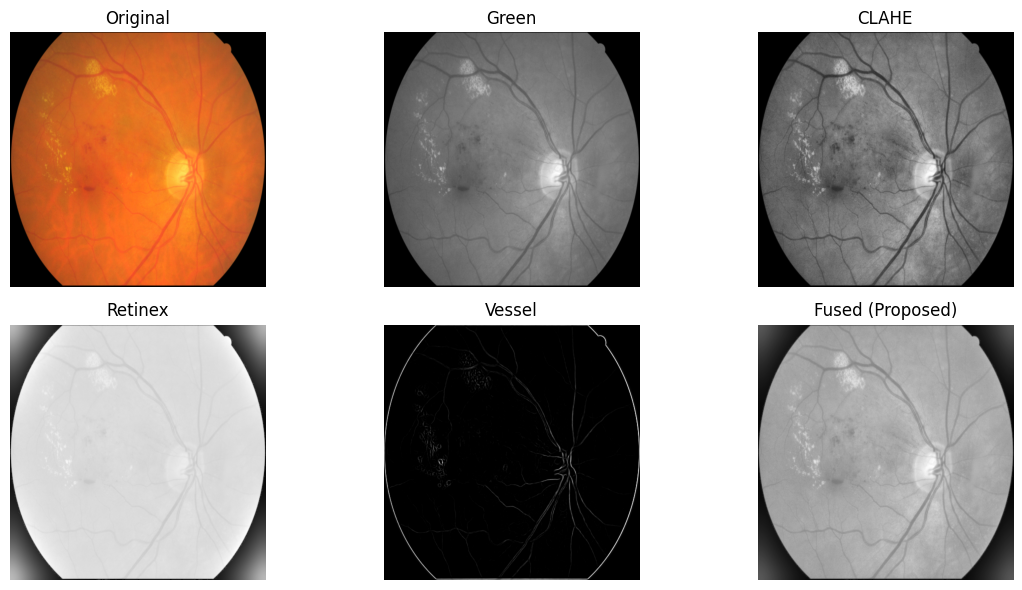

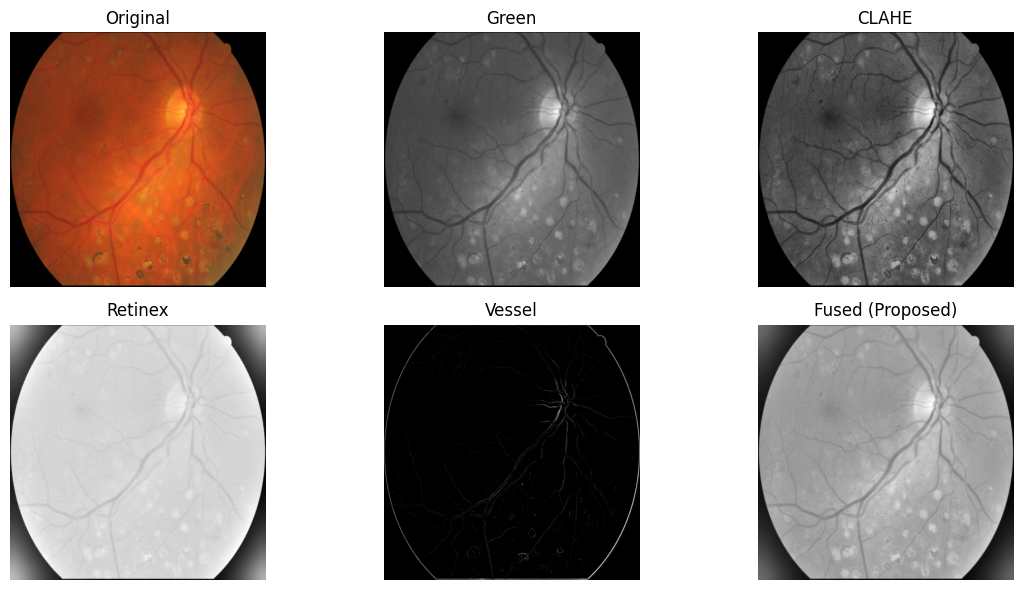

✅ Preprocessing complete!

📊 Average Metrics:
Entropy: 6.2155
CII: 1.1194
EPI: 0.9126


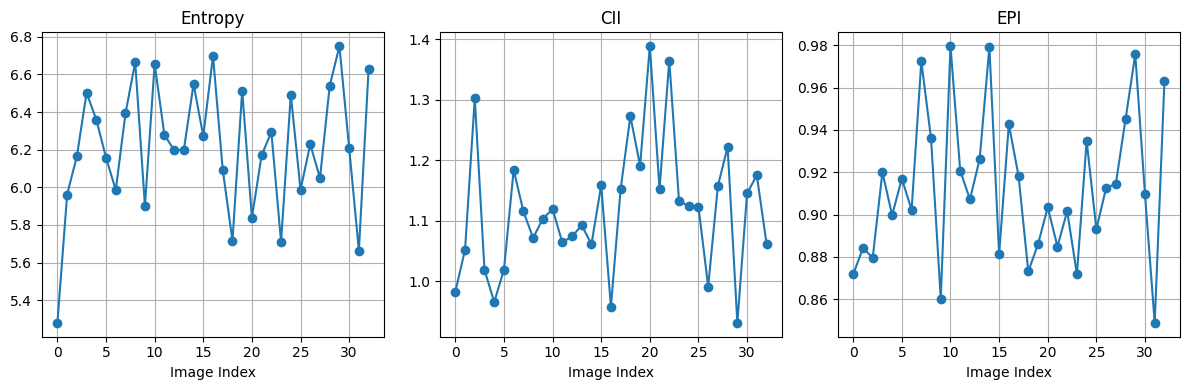


📊 Statistical Results:
Entropy: Mean=6.2155, Std=0.3379
CII: Mean=1.1194, Std=0.1071
EPI: Mean=0.9126, Std=0.0345


In [2]:
!pip install opencv-python scikit-image matplotlib numpy

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from skimage.filters import frangi

# =============================
# MOUNT DRIVE
# =============================
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/GlaucomaDataset/G1020"
input_dir = os.path.join(base_dir, "Images")
output_dir = os.path.join(base_dir, "preprocessed_outputs")
os.makedirs(output_dir, exist_ok=True)

print("Input:", input_dir)
print("Output:", output_dir)

# =============================
# PREPROCESSING METHODS
# =============================

def green_channel(img):
    return img[:,:,1]

def apply_clahe(gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(gray)

def single_scale_retinex(img, sigma=30):
    img = np.float32(img) + 1.0
    blur = cv2.GaussianBlur(img, (0,0), sigma)
    retinex = np.log(img) - np.log(blur + 1e-5)
    return cv2.normalize(retinex, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def vessel_enhance(gray):
    vessel = frangi(gray/255.)
    vessel = cv2.normalize(vessel, None, 0, 255, cv2.NORM_MINMAX)
    return vessel.astype(np.uint8)

def adaptive_fusion(green, clahe, retinex, vessel):
    g = green / 255.
    c = clahe / 255.
    r = retinex / 255.
    v = vessel / 255.

    wg = np.var(g)
    wc = np.var(c)
    wr = np.var(r)
    wv = np.var(v)

    total = wg + wc + wr + wv + 1e-6

    fused = (wg*g + wc*c + wr*r + wv*v) / total
    return np.clip(fused*255, 0, 255).astype(np.uint8)

# =============================
# METRICS
# =============================

def compute_entropy(img):
    hist = cv2.calcHist([img],[0],None,[256],[0,256])
    hist = hist.ravel() / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))

def compute_cii(original, enhanced):
    def rms(img):
        img = img / 255.0
        mean = np.mean(img)
        return np.sqrt(np.mean((img - mean) ** 2))

    return rms(enhanced) / (rms(original) + 1e-8)

def compute_epi(original, enhanced):
    sobel_orig = cv2.Sobel(original, cv2.CV_64F, 1, 1, ksize=3)
    sobel_enh = cv2.Sobel(enhanced, cv2.CV_64F, 1, 1, ksize=3)

    num = np.sum(sobel_orig * sobel_enh)
    den = np.sqrt(np.sum(sobel_orig**2) * np.sum(sobel_enh**2)) + 1e-8

    return num / den

# =============================
# PROCESS IMAGES
# =============================

entropy_list = []
cii_list = []
epi_list = []

count = 0

for img_name in os.listdir(input_dir):
    if not img_name.lower().endswith((".jpg",".png",".jpeg")):
        continue

    path = os.path.join(input_dir, img_name)
    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.resize(img, (512,512))

    green = green_channel(img)
    clahe = apply_clahe(green)
    retinex = single_scale_retinex(green)
    vessel = vessel_enhance(green)

    fused = adaptive_fusion(green, clahe, retinex, vessel)

    # =============================
    # SAVE OUTPUTS
    # =============================
    cv2.imwrite(os.path.join(output_dir, f"{img_name}_green.png"), green)
    cv2.imwrite(os.path.join(output_dir, f"{img_name}_clahe.png"), clahe)
    cv2.imwrite(os.path.join(output_dir, f"{img_name}_retinex.png"), retinex)
    cv2.imwrite(os.path.join(output_dir, f"{img_name}_vessel.png"), vessel)
    cv2.imwrite(os.path.join(output_dir, f"{img_name}_fused.png"), fused)

    # =============================
    # METRICS
    # =============================
    entropy_list.append(compute_entropy(fused))
    cii_list.append(compute_cii(green, fused))
    epi_list.append(compute_epi(green, fused))

    # =============================
    # SHOW SAMPLE RESULTS
    # =============================
    if count < 3:
        plt.figure(figsize=(12,6))

        plt.subplot(2,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
        plt.subplot(2,3,2); plt.imshow(green, cmap='gray'); plt.title("Green"); plt.axis("off")
        plt.subplot(2,3,3); plt.imshow(clahe, cmap='gray'); plt.title("CLAHE"); plt.axis("off")
        plt.subplot(2,3,4); plt.imshow(retinex, cmap='gray'); plt.title("Retinex"); plt.axis("off")
        plt.subplot(2,3,5); plt.imshow(vessel, cmap='gray'); plt.title("Vessel"); plt.axis("off")
        plt.subplot(2,3,6); plt.imshow(fused, cmap='gray'); plt.title("Fused (Proposed)"); plt.axis("off")

        plt.tight_layout()
        plt.show()

    count += 1

print("✅ Preprocessing complete!")

# =============================
# FINAL METRICS
# =============================
print("\n📊 Average Metrics:")
print(f"Entropy: {np.mean(entropy_list):.4f}")
print(f"CII: {np.mean(cii_list):.4f}")
print(f"EPI: {np.mean(epi_list):.4f}")

# =============================
# PLOTS
# =============================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(entropy_list, marker='o')
plt.title("Entropy")
plt.xlabel("Image Index")
plt.grid()

plt.subplot(1,3,2)
plt.plot(cii_list, marker='o')
plt.title("CII")
plt.xlabel("Image Index")
plt.grid()

plt.subplot(1,3,3)
plt.plot(epi_list, marker='o')
plt.title("EPI")
plt.xlabel("Image Index")
plt.grid()

plt.tight_layout()
plt.show()

print("\n📊 Statistical Results:")
print(f"Entropy: Mean={np.mean(entropy_list):.4f}, Std={np.std(entropy_list):.4f}")
print(f"CII: Mean={np.mean(cii_list):.4f}, Std={np.std(cii_list):.4f}")
print(f"EPI: Mean={np.mean(epi_list):.4f}, Std={np.std(epi_list):.4f}")